In [3]:
import seaborn as sns
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0
...,...,...,...,...,...,...,...,...,...
1995,2,75,64,24,55,29.7,0.370,33,0
1996,8,179,72,42,130,32.7,0.719,36,1
1997,6,85,78,0,0,31.2,0.382,42,0
1998,0,129,110,46,130,67.1,0.319,26,1


In [5]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


In [7]:
df.shape

(2000, 9)

In [32]:
df.describe

<bound method NDFrame.describe of       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0               2      138             62             35       40  33.6   
1               0       84             82             31      125  38.2   
2               0      145             72             23       40  44.2   
3               0      135             68             42      250  42.3   
4               1      139             62             41      480  40.7   
...           ...      ...            ...            ...      ...   ...   
1995            2       75             64             24       55  29.7   
1996            8      179             72             42      130  32.7   
1997            6       85             78             23       40  31.2   
1998            0      129            110             46      130  67.1   
1999            2       81             72             15       76  30.1   

      DiabetesPedigreeFunction  Age  Outcome  
0                 

In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

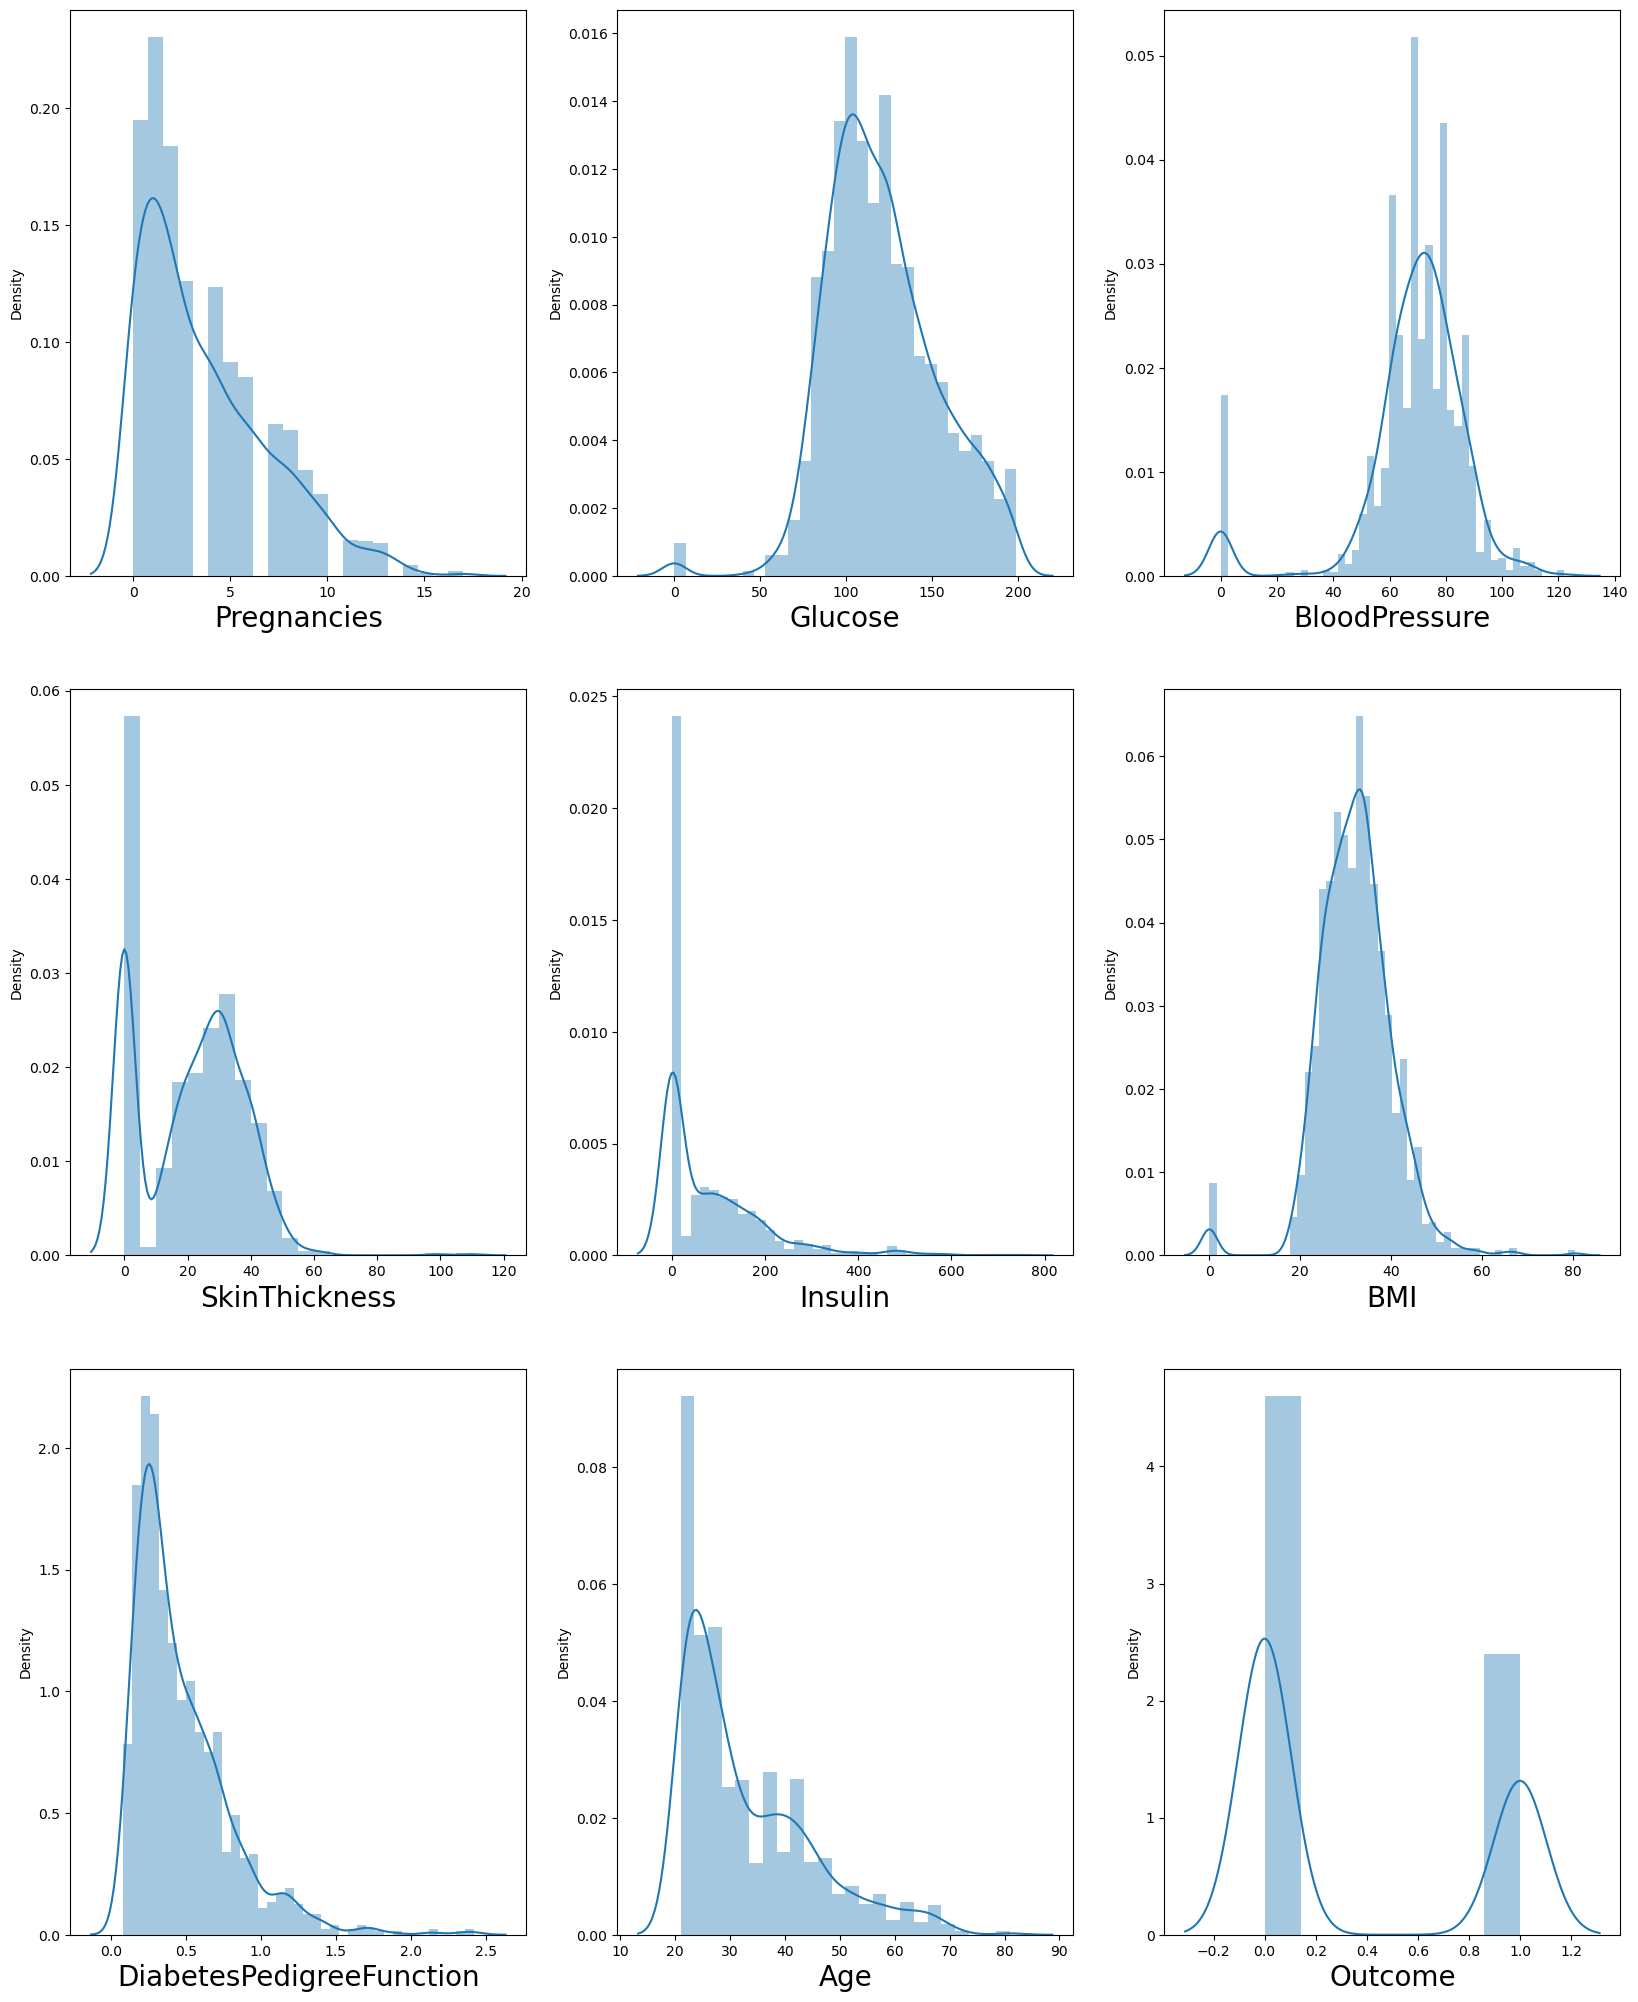

In [21]:
plt.figure(figsize=(20,25),facecolor='white')
plotnumber=1
for column in df:
    if plotnumber<=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.distplot(df[column])
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.show()

# insights for the 

In [24]:
# some columns have 0 values like glucose and in some columns values
# it is not posible to give 0 value in glucose even without having the missing values
# thats why i remove the o values with median values

In [26]:
df['BMI']=df['BMI'].replace(0,df['BMI'].median())
df['BloodPressure']=df['BloodPressure'].replace(0,df['BloodPressure'].median())
df['Insulin']=df['Insulin'].replace(0,df['Insulin'].median())
df['SkinThickness']=df['SkinThickness'].replace(0,df['SkinThickness'].median())

# insights for below graphs

Pregnancies → Yes, clear effect (higher values → more diabetes)

Glucose → Yes, very strong effect

BloodPressure → Yes, small but noticeable effect

DiabetesPedigreeFunction → Yes, moderate effect

SkinThickness → No, very weak effect

Insulin → No, weak and noisy effect

BMI → Slight effect, but not strong alone

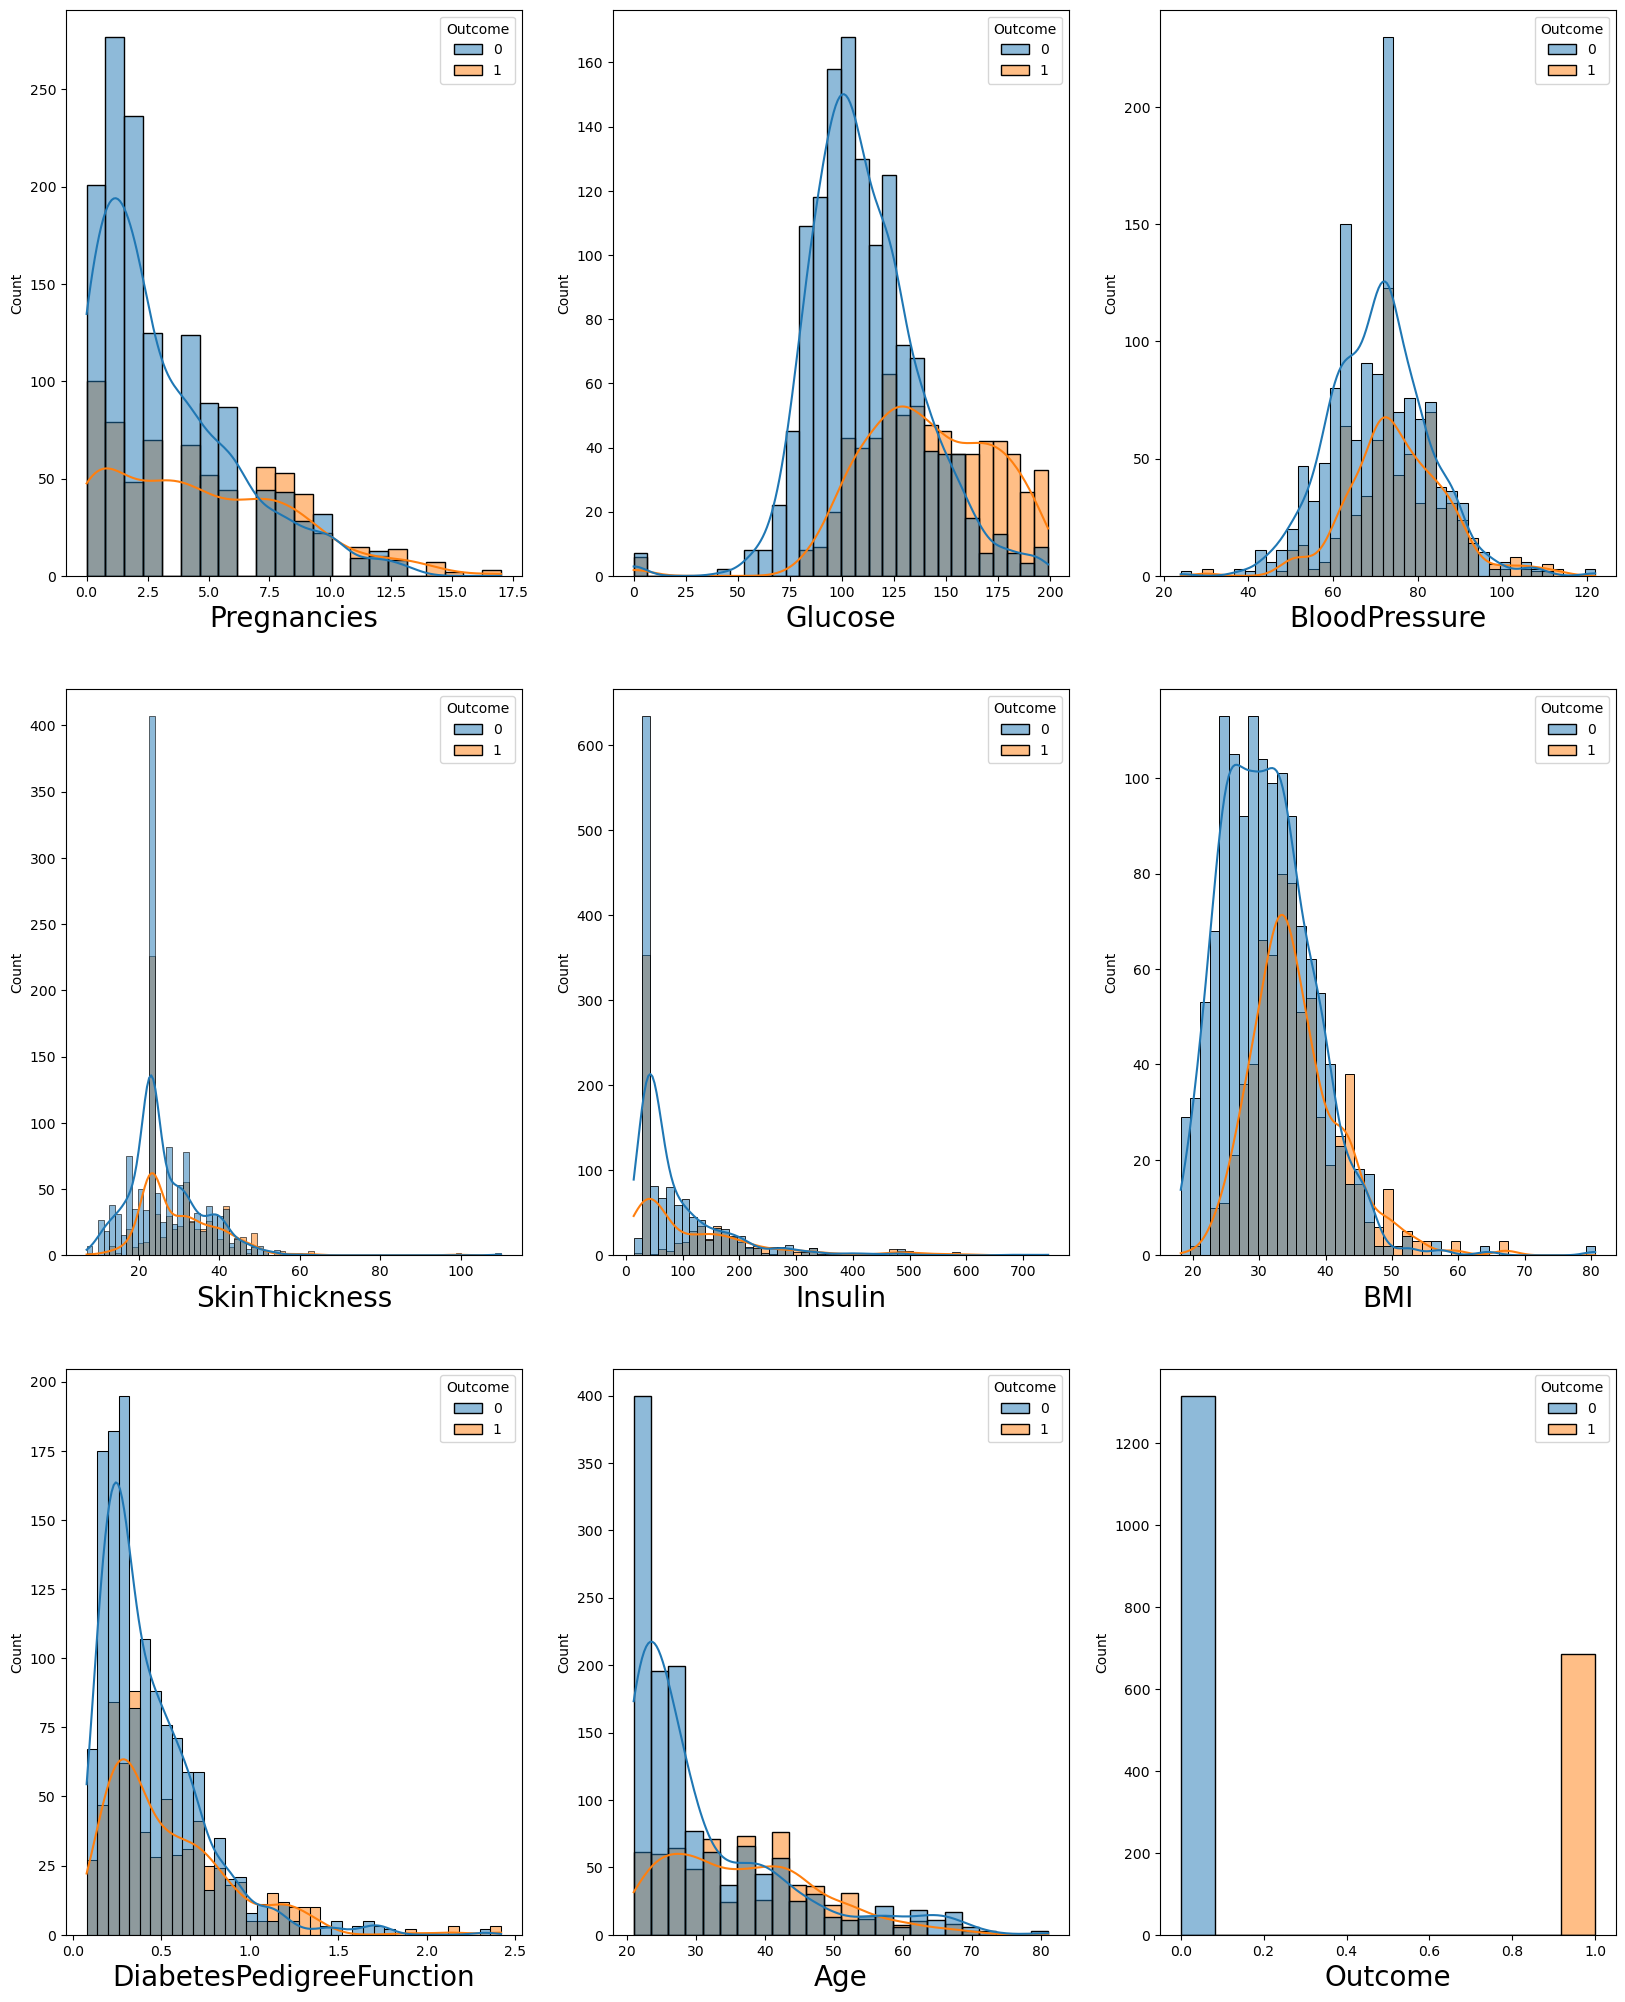

In [27]:

plt.figure(figsize=(20,25),facecolor='white')
plotnumber=1
for column in df:
    if plotnumber<=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.histplot(x=df[column],hue=df['Outcome'],kde=True)
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.show()

In [35]:
from scipy import stats
import statsmodels.api as sm

Glucose_pos=df[df['Outcome']==1]['Glucose']
Glucose_negative=df[df['Outcome']==0]['Glucose']

In [ ]:
# using hypothisis testing ->(T.Test) using this ml model 
# we only test the 2000 we can conclude or predict the 20 millions of data 

In [36]:
t_stat,p_val=stats.ttest_ind(Glucose_pos,Glucose_negative)
print("Indepentent T-test statistic:",t_stat)
print("P-value:",p_val)#1.72
if p_val<0.05:
    print("reject null hypothesis")
else:
    print("fail to reject the hypothesis")

Indepentent T-test statistic: 23.05633354719803
P-value: 1.724006801539328e-104
reject null hypothesis


#T-Test
**defination** t-test is used to compare means when the polulation variance is unknown 
or hte simple size is small

#independent t-test
**example** compare

In [37]:
from scipy import stats
import statsmodels.api as sm

P_pos=df[df['Outcome']==1]['Pregnancies']
P_neg=df[df['Outcome']==0]['Pregnancies']

In [38]:
t_stat,p_val=stats.ttest_ind(P_pos,P_neg)
print("Indepentent T-test statistic:",t_stat)
print("P-value:",p_val)#2.96
if p_val<0.05:
    print("reject null hypothesis")
else:
    print("fail to reject the hypothesis")

Indepentent T-test statistic: 10.294740851256517
P-value: 2.968017579508808e-24
reject null hypothesis


In [39]:
from scipy import stats
import statsmodels.api as sm

blood_pos=df[df['Outcome']==1]['BloodPressure']
blood_neg=df[df['Outcome']==0]['BloodPressure']

In [40]:
t_stat,p_val=stats.ttest_ind(blood_pos,blood_neg)
print("Indepentent T-test statistic:",t_stat)
print("P-value:",p_val)#0.006
if p_val<0.05:
    print("reject null hypothesis")
else:
    print("fail to reject the hypothesis")

Indepentent T-test statistic: 3.405087124758126
P-value: 0.0006745060979594841
reject null hypothesis


In [23]:
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


In [41]:
from scipy import stats
import statsmodels.api as sm

skin_pos=df[df['Outcome']==1]['SkinThickness']
skin_neg=df[df['Outcome']==0]['SkinThickness']

In [44]:
t_stat,p_val=stats.ttest_ind(skin_pos,skin_neg)
print("Indepentent T-test statistic:",t_stat)
print("P-value:",p_val)#0.0006
if p_val<0.05:
    print("reject null hypothesis")
else:
    print("fail to reject the hypothesis")

Indepentent T-test statistic: 3.408791795158821
P-value: 0.0006654655716421974
reject null hypothesis


In [43]:
from scipy import stats
import statsmodels.api as sm

i_pos=df[df['Outcome']==1]['Insulin']
i_neg=df[df['Outcome']==0]['Insulin']

In [45]:
t_stat,p_val=stats.ttest_ind(i_pos,i_neg)
print("Indepentent T-test statistic:",t_stat)
print("P-value:",p_val)#5.814
if p_val<0.05:
    print("reject null hypothesis")
else:
    print("fail to reject the hypothesis")

Indepentent T-test statistic: 5.4451214714667575
P-value: 5.814837239580342e-08
reject null hypothesis


In [29]:
from scipy import stats
import statsmodels.api as sm

bmi_pos=df[df['Outcome']==1]['BMI']
bmi_neg=df[df['Outcome']==0]['BMI']

In [46]:
t_stat,p_val=stats.ttest_ind(bmi_pos,bmi_neg)
print("Indepentent T-test statistic:",t_stat)
print("P-value:",p_val)#1.74
if p_val<0.05:
    print("reject null hypothesis")
else:
    print("fail to reject the hypothesis")

Indepentent T-test statistic: 12.872018209762171
P-value: 1.7467634881773225e-36
reject null hypothesis


In [31]:
from scipy import stats
import statsmodels.api as sm

dia_pos=df[df['Outcome']==1]['DiabetesPedigreeFunction']
dia_neg=df[df['Outcome']==0]['DiabetesPedigreeFunction']

In [32]:
t_stat,p_val=stats.ttest_ind(dia_pos,dia_neg)
print("Indepentent T-test statistic:",t_stat)
print("P-value:",p_val)#2.73
if p_val<0.05:
    print("reject null hypothesis")
else:
    print("fail to reject the hypothesis")

Indepentent T-test statistic: 7.034386057932806
P-value: 2.7384134507979468e-12
reject null hypothesis


In [33]:
from scipy import stats
import statsmodels.api as sm

age_pos=df[df['Outcome']==1]['Age']
age_neg=df[df['Outcome']==0]['Age']

In [34]:
t_stat,p_val=stats.ttest_ind(age_pos,age_neg)
print("Indepentent T-test statistic:",t_stat)
print("P-value:",p_val)#
if p_val<0.05:
    print("reject null hypothesis")
else:
    print("fail to reject the hypothesis")

Indepentent T-test statistic: 10.880410795440374
P-value: 7.948733933404598e-27
reject null hypothesis


#Pregnancies	->2.968017579508808e-24
#Glucose->1.724006801539328e-104
#BloodPressure->0.0006745060979594841
#SkinThickness	->0.0006654655716421974
#Insulin->5.814837239580342e-08
#BMI->1.7467634881773225e-36
#DiabetesPedigreeFunction-> 2.7384134507979468e-12
#Age	Outcome-> 7.948733933404598e-27


In [54]:
x=df.drop(columns=['Outcome'])
y=df['Outcome']

In [56]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
x_scaled=scalar.fit_transform(x)
x_scaled

array([[-0.5153943 ,  0.52455322, -0.37248123, ...,  0.17268332,
        -1.06324616,  1.18042417],
       [-1.12049474, -1.1597562 ,  0.67008046, ...,  0.73724853,
        -0.7355513 , -0.85632626],
       [-1.12049474,  0.74288962, -3.60442246, ...,  1.47363794,
         0.49175869, -0.17740945],
       ...,
       [ 0.69480658, -1.12856529,  0.46156812, ..., -0.12187245,
        -0.27492362,  0.75610116],
       [-1.12049474,  0.24383498,  2.12966682, ...,  4.28419085,
        -0.46968566, -0.60173245],
       [-0.5153943 , -1.25332895,  0.14879962, ..., -0.25687717,
         0.23516743, -0.68659705]])

In [58]:
#mean of the glucose
df['Glucose'].mean()

np.float64(121.1825)

In [59]:
#Standardization
df['Glucose'].std()

32.0686356499029

In [62]:
from sklearn.preprocessing import MinMaxScaler

norm = MinMaxScaler()
x_scaled_norm = norm.fit_transform(x)

x_scaled_norm = pd.DataFrame(x_scaled_norm, columns=x.columns)
x_scaled_norm.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.217853,0.608957,0.566766,0.190318,0.107868,0.399417,0.167775,0.201508
std,0.194474,0.161149,0.157281,0.146393,0.149436,0.101115,0.138152,0.196440
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.058824,0.497487,0.520492,0.000000,0.000000,0.339640,0.070880,0.050000
50%,0.176471,0.587940,0.590164,0.209091,0.053763,0.400744,0.127242,0.133333
75%,0.352941,0.708543,0.655738,0.290909,0.174731,0.456576,0.233134,0.316667
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [65]:
 #divide into x and y
x=df.drop("Outcome", axis=1)
y=df["Outcome"]

In [68]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_scaled,y,test_size=0.2,random_state=42,stratify=y)


In [71]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

error_rate = []

for i in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    
    pred_i = knn.predict(x_test)
    error_rate.append(np.mean(pred_i != y_test))

error_rate


[np.float64(0.0075),
 np.float64(0.08),
 np.float64(0.1475),
 np.float64(0.195),
 np.float64(0.19),
 np.float64(0.19),
 np.float64(0.1775),
 np.float64(0.195),
 np.float64(0.1975),
 np.float64(0.2)]

In [30]:
#divide into x and y
x=df.drop("Outcome", axis=1)
y=df["Outcome"]

In [36]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=78)

In [37]:
#train the models
from sklearn.linear_model import LogisticRegression

#load the model
model=LogisticRegression()

#fit the model
train_model=model.fit(x_train,y_train)


#make predictions
y_pred=train_model.predict(x_test)
y_pred

E:\anaconda\new\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [38]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy of Logistic Regession model is:", accuracy)

Accuracy of Logistic Regession model is: 0.795


In [34]:
#check the loss function
from sklearn.metrics import log_loss
logloss=log_loss(y_test,y_pred)
print("Log loss of Logistic Regression model is: ",logloss)

Log loss of Logistic Regression model is:  7.388948944769016


In [16]:
print("MSE : ",mean_squared_error(y_test,y_predict))
print("MAE : ",mean_absolute_error(y_test,y_predict))
print("RMSE : ",root_mean_squared_error(y_test,y_predict))

MSE :  0.1565253478636807
MAE :  0.331872523639361
RMSE :  0.3956328447736369


In [35]:
#combine actual vs predicted
comparison=pd.DataFrame({"actual ":y_test,"prediction ":y_pred})
comparison


,actual,prediction
1860,1,1
353,0,0
1333,1,1
905,1,1
1289,1,1
...,...,...
965,0,1
1284,0,0
1739,0,0
261,1,1
